# 050. 형태소 분석 (POS tag, part-of-speech tag)

- 품사 부착 혹은 POS tag (part-of-speech tag) 라 부름  

- 원시 말뭉치를 형태소 단위로 쪼개고 각 형태소에 품사 정보를 부착하는 작업  

- 형태소는 언어별로 다르고, 비슷한 언어간에는 유사하나 연관성이 없는 단어간에는 완전히 다름  

- 가장 기본적으로는 명사, 동사, 형용사 등으로 나눌 수 있으나 이를 단, 복수형 명사, 동사 변화, 시제 변화 등 더 자세히 나눌 수 있음.  

- 한글의 경우, KoNLPy는 시중에 공개된 꼬꼬마, 코모란, 트위터, 한나눔, 은전한닢 다섯개의 형태소 분석기를 한꺼번에 묶어서 편리하게 사용할 수 있도록 한 패키지

# 형태소의 용도 및 작성법

- 형태소는 각 단어가 어떤 품사인지 고려하여 자동 문장 처리를 가능하도록 한다.  이를 이용하여 언어의 통계적 처리가 가능  

- 영어와 같이 동일한 단어가 다른 품사를 가지는 언어의 경우 품사 tagging 에 의해 그 단어가 명사로 사용 되었는지 동사로 사용되었는지 구분할 수 있다.  

- 수작업 tagging 은 large corpus 에서는 거의 불가능하고, small corpus 에서 training data 용으로 사용  

- 여러 언어를 처리하는 tagger 도 있으나, 각 언어별 tagger 들은 서로 관련성 없을 수 있고, 각각 다른 접근법과 알고리즘 및 프로그램 언어를 사용할 수 있다.

## Keras 를 이용한 LSTM POS tagger 작성

- Bidirectional LSTM 으로 POS tagger 작성  


- nltk 내장 corpus 를 이용하여 training  
    - nltk.corpus.treebank.tagged_sents() 사용

In [1]:
!pip install konlpy

     |████████████████████████████████| 19.4MB 1.6MB/s 
     |████████████████████████████████| 92kB 8.0MB/s 
     |████████████████████████████████| 2.9MB 38.7MB/s 
  Found existing installation: tweepy 3.6.0
    Uninstalling tweepy-3.6.0:
      Successfully uninstalled tweepy-3.6.0
  Found existing installation: beautifulsoup4 4.6.3
    Uninstalling beautifulsoup4-4.6.3:
      Successfully uninstalled beautifulsoup4-4.6.3


In [0]:
import re
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Activation
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
import nltk
from konlpy.tag import Okt

## treebank corpus download

In [56]:
nltk.download('treebank')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [57]:
tagged_sentences = nltk.corpus.treebank.tagged_sents()

print(tagged_sentences[100])
print(' '.join([word for (word, tag) in tagged_sentences[100]]))
print()
print("Total tagged sentences :", len(tagged_sentences))
print("Total tagged words :", len(nltk.corpus.treebank.tagged_words()))

[('Alan', 'NNP'), ('Spoon', 'NNP'), (',', ','), ('recently', 'RB'), ('named', 'VBN'), ('*', '-NONE-'), ('Newsweek', 'NNP'), ('president', 'NN'), (',', ','), ('said', 'VBD'), ('0', '-NONE-'), ('Newsweek', 'NNP'), ("'s", 'POS'), ('ad', 'NN'), ('rates', 'NNS'), ('would', 'MD'), ('increase', 'VB'), ('5', 'CD'), ('%', 'NN'), ('in', 'IN'), ('January', 'NNP'), ('.', '.')]
Alan Spoon , recently named * Newsweek president , said 0 Newsweek 's ad rates would increase 5 % in January .

Total tagged sentences : 3914
Total tagged words : 100676


### input, label data 작성을 위해 단어와 tag 를 분리

In [58]:
list(zip(*[( 'book', 'noun'), ('is', 'verb'), ('cat', 'noun')]))

[('book', 'is', 'cat'), ('noun', 'verb', 'noun')]

In [59]:
sentences, sentence_tags =[], [] 

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

# Let's see how a sequence looks
print(sentences[5])
print(sentence_tags[5])

['Lorillard', 'Inc.', ',', 'the', 'unit', 'of', 'New', 'York-based', 'Loews', 'Corp.', 'that', '*T*-2', 'makes', 'Kent', 'cigarettes', ',', 'stopped', 'using', 'crocidolite', 'in', 'its', 'Micronite', 'cigarette', 'filters', 'in', '1956', '.']
['NNP', 'NNP', ',', 'DT', 'NN', 'IN', 'JJ', 'JJ', 'NNP', 'NNP', 'WDT', '-NONE-', 'VBZ', 'NNP', 'NNS', ',', 'VBD', 'VBG', 'NN', 'IN', 'PRP$', 'NN', 'NN', 'NNS', 'IN', 'CD', '.']


샘플의 최대 길이 : 271
샘플의 평균 길이 : 25.722024


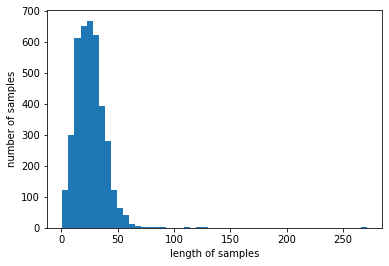

In [60]:
print('샘플의 최대 길이 : {}'.format(max([len(w) for w in sentences])))
print('샘플의 평균 길이 : {:4f}'.format(np.mean([len(w) for w in sentences])))
plt.hist([len(s) for s in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

**sample 들의 길이가 대체적으로 0-100의 길이를 가지며, 특히 0-50의 길이를 가진 샘플이 상당한 비율을 차지**

**keras 는 fixed size sequence 만 handling 가능하므로 max sequence length 를 100 으로 정함**

In [0]:
MAX_LENGTH = 100

### 전체 word 수 check

In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

11387


**전체 token 갯수가 11387 개 이므로 embedding 은 상위 4000 개로 제한**

- 문장 데이터에 대해서는 input_tokenizer를, 레이블에 해당되는 개체명 태깅 정보에 대해서는 tag_tokenizer를 사용  

In [0]:
MAX_WORDS = 4000

### train, test split

In [0]:
train_sentences, test_sentences, train_tags, test_tags \
                = train_test_split(sentences, sentence_tags, test_size=0.2)

### train data 는 train_sentences 에 대해 tokenize 하고 label 은 분류 class 역할을 하므로 전체 sentence_tags 에 대해 tokenize

- model 은 train 시 validation data 를 볼 수 없어야 함

In [15]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)
print(list(input_tokenizer.index_word.items())[:10])

[(1, '<OOV>'), (2, ','), (3, 'the'), (4, '.'), (5, 'of'), (6, 'to'), (7, 'a'), (8, 'in'), (9, 'and'), (10, '*-1')]


In [16]:
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)
tag_tokenizer.index_word[0] = '<pad>'
tag_tokenizer.word_index['<pad>'] = 0
print(list(tag_tokenizer.index_word.items()))

[(1, 'nn'), (2, 'in'), (3, 'nnp'), (4, 'dt'), (5, '-none-'), (6, 'nns'), (7, 'jj'), (8, ','), (9, '.'), (10, 'cd'), (11, 'vbd'), (12, 'rb'), (13, 'vb'), (14, 'cc'), (15, 'to'), (16, 'vbn'), (17, 'vbz'), (18, 'prp'), (19, 'vbg'), (20, 'vbp'), (21, 'md'), (22, 'pos'), (23, 'prp$'), (24, '$'), (25, '``'), (26, "''"), (27, ':'), (28, 'wdt'), (29, 'jjr'), (30, 'nnps'), (31, 'wp'), (32, 'rp'), (33, 'jjs'), (34, 'wrb'), (35, 'rbr'), (36, '-rrb-'), (37, '-lrb-'), (38, 'ex'), (39, 'rbs'), (40, 'pdt'), (41, '#'), (42, 'wp$'), (43, 'ls'), (44, 'fw'), (45, 'uh'), (46, 'sym'), (0, '<pad>')]


In [17]:
vocab_size = min(MAX_WORDS, len(input_tokenizer.word_index))
tag_size = len(tag_tokenizer.word_index) 

print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 4000
개체명 태깅 정보 집합의 크기 : 47


### sentence 와 tag 를 sequence 로 변환

In [18]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

len(X_train), len(y_train), len(X_test), len(y_test)

(3131, 3131, 783, 783)

- sequence padding

In [19]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[0])
print(test_sentences_X[0])
print(train_tags_y[0])
print(test_tags_y[0])

[  45   33   24    3  136    5   39  440   49   28  161  392    2   44
   45 2458   11   45  173   94    1    5   23    4    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[ 405  347   14  166  157  403  500    3    1    5   12  993   62  464
 1203    1    4    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

### n-to-n model 이므로 return_sequences=True 로 설정

In [109]:
def pos_model(vocab_size, tag_size):
    model = Sequential()
    model.add(Embedding(vocab_size+1, 128))
    model.add(Bidirectional(LSTM(256, return_sequences=True)))
    model.add(Dense(tag_size))
    model.add(Activation('softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

    model.summary()
    return model

model = pos_model(vocab_size, tag_size)

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, None, 128)         384256    
_________________________________________________________________
bidirectional_3 (Bidirection (None, None, 512)         788480    
_________________________________________________________________
dense_3 (Dense)              (None, None, 12)          6156      
_________________________________________________________________
activation_3 (Activation)    (None, None, 12)          0         
Total params: 1,178,892
Trainable params: 1,178,892
Non-trainable params: 0
_________________________________________________________________


In [21]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)

print(cat_train_tags_y[0])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [22]:
%%time
model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=50, 
                          validation_data=(test_sentences_X, cat_test_tags_y ))

Epoch 1/50
25/25 [==============================] - 4s 142ms/step - loss: 1.5968 - accuracy: 0.7204 - val_loss: 0.9014 - val_accuracy: 0.7411
Epoch 2/50
25/25 [==============================] - 2s 98ms/step - loss: 0.8504 - accuracy: 0.7536 - val_loss: 0.8278 - val_accuracy: 0.7713
Epoch 3/50
25/25 [==============================] - 2s 98ms/step - loss: 0.8016 - accuracy: 0.7780 - val_loss: 0.7886 - val_accuracy: 0.7781
Epoch 4/50
25/25 [==============================] - 2s 98ms/step - loss: 0.7607 - accuracy: 0.7820 - val_loss: 0.7584 - val_accuracy: 0.7798
Epoch 5/50
25/25 [==============================] - 2s 98ms/step - loss: 0.7360 - accuracy: 0.7933 - val_loss: 0.7352 - val_accuracy: 0.7896
Epoch 6/50
25/25 [==============================] - 2s 98ms/step - loss: 0.7084 - accuracy: 0.8139 - val_loss: 0.6997 - val_accuracy: 0.8308
Epoch 7/50
25/25 [==============================] - 2s 98ms/step - loss: 0.6576 - accuracy: 0.8490 - val_loss: 0.6240 - val_accuracy: 0.8551
Epoch 8/50
2

In [23]:
model.metrics_names

['loss', 'accuracy']

In [24]:
scores = model.evaluate(test_sentences_X, cat_test_tags_y, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")   

accuracy: 97.58875966072083


In [25]:
test_samples = [
     "running is very important to me .".split(),
    "I was running every day for a month .".split()
]
print(test_samples)

[['running', 'is', 'very', 'important', 'to', 'me', '.'], ['I', 'was', 'running', 'every', 'day', 'for', 'a', 'month', '.']]


In [0]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [27]:
test_samples_X

array([[3053,   21,  371,  710,    6, 1500,    4,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [  82,   33, 3053,  564,  470,   15,    7,  204,    4,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    

In [0]:
index2word = input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [29]:
y_predicted = model.predict_classes(test_samples_X)

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


In [30]:
y_predicted

array([[ 3, 17, 12,  7, 15, 18,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [18, 11, 19,  4,  1,  2,  4,  1,  9,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0]])

In [32]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], 
                    [index2tag[yhat] for yhat in y_predicted[i]]):
        if w != '<OOV>' and w != '?':
            print(f'{w} : {t.upper()}')
    print()

running : NNP
is : VBZ
very : RB
important : JJ
to : TO
me : PRP
. : .

i : PRP
was : VBD
running : VBG
every : DT
day : NN
for : IN
a : DT
month : NN
. : .



In [33]:
print(nltk.pos_tag(test_samples[0]))
print(nltk.pos_tag(test_samples[1]))

[('running', 'NN'), ('is', 'VBZ'), ('very', 'RB'), ('important', 'JJ'), ('to', 'TO'), ('me', 'PRP'), ('.', '.')]
[('I', 'PRP'), ('was', 'VBD'), ('running', 'VBG'), ('every', 'DT'), ('day', 'NN'), ('for', 'IN'), ('a', 'DT'), ('month', 'NN'), ('.', '.')]


## 한글 품사 tagging

- Okt 를 이용  

- 한글 어린왕자 corpus 이용  

In [61]:
okt = Okt()

file_path = tf.keras.utils.get_file("young-prince.txt", "https://raw.githubusercontent.com/ironmanciti/NLP_Lecture/master/data/young_prince.txt")

f = open(file_path, encoding='utf-8')
text = f.readlines()
text[:2]

['여섯 살 적에 나는 "체험한 이야기"라는 제목의, 원시림에 관한 책에서 기막힌 그림 하나를 본 적이 있다. 맹수를 집어삼키고 있는 보아 구렁이 그림이었다. 위의 그림은 그것을 옮겨 그린 것이다.\n',
 '  그 책에는 이렇게 씌어 있었다.\n']

In [62]:
tagged_sentences= []

for line in text:
    line = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', line)    #한글 only
    line = okt.pos(line)   # 품사 tagging
    if len(line) > 0:
        tagged_sentences.append(line)

print('total tagged sentences: ', len(tagged_sentences))
print(tagged_sentences[0])

total tagged sentences:  951
[('여섯', 'Noun'), ('살', 'Noun'), ('적', 'Noun'), ('에', 'Josa'), ('나', 'Noun'), ('는', 'Josa'), ('체험', 'Noun'), ('한', 'Josa'), ('이야기', 'Noun'), ('라는', 'Josa'), ('제목', 'Noun'), ('의', 'Josa'), ('원시림', 'Noun'), ('에', 'Josa'), ('관', 'Noun'), ('한', 'Josa'), ('책', 'Noun'), ('에서', 'Josa'), ('기막힌', 'Adjective'), ('그림', 'Noun'), ('하나', 'Noun'), ('를', 'Josa'), ('본', 'Verb'), ('적', 'Noun'), ('이', 'Josa'), ('있다', 'Adjective'), ('맹수', 'Noun'), ('를', 'Josa'), ('집어', 'Verb'), ('삼키고', 'Verb'), ('있는', 'Adjective'), ('보아', 'Noun'), ('구렁이', 'Noun'), ('그림이었다', 'Verb'), ('위', 'Noun'), ('의', 'Josa'), ('그림', 'Noun'), ('은', 'Josa'), ('그것', 'Noun'), ('을', 'Josa'), ('옮겨', 'Verb'), ('그린', 'Noun'), ('것', 'Noun'), ('이다', 'Josa')]


In [66]:
sentences = []
sentence_tags = []

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

print(sentences[5])
print(sentence_tags[5])

['그', '들', '은', '모자', '가', '뭐', '가', '무섭다는', '거니', '하고', '대답', '했다']
['Noun', 'Suffix', 'Josa', 'Noun', 'Josa', 'Noun', 'Josa', 'Adjective', 'Eomi', 'Verb', 'Noun', 'Verb']


샘플의 최대 길이 : 184
샘플의 평균 길이 : 17.325973


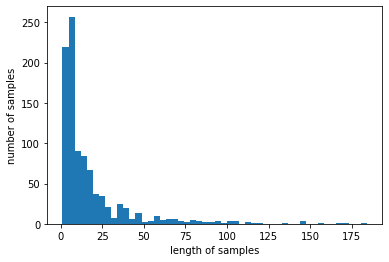

In [67]:
print('샘플의 최대 길이 : {}'.format(max(len(sentence) for sentence in sentences)))
print('샘플의 평균 길이 : {:4f}'.format(sum(map(len, sentences))/len(sentences)))
plt.hist([len(sentence) for sentence in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

- sample 의 평균 길이가 25.7 이므로 50 을 max length 로 정함  


In [0]:
MAX_LENGTH = 50

### 전체 word 수 check

In [112]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

3419


### 전체 word 수가 3419 이므로 MAX_WORDS 는 3000 으로 정함

In [0]:
MAX_WORDS = 3000

### train, test set 분리

In [114]:
train_sentences, test_sentences, train_tags, test_tags \
                = train_test_split(sentences, sentence_tags, test_size=0.2)

len(train_sentences), len(test_sentences), len(train_tags), len(test_tags)

(760, 191, 760, 191)

### tokenization

In [122]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)
tag_tokenizer.index_word[0] = '<pad>'
tag_tokenizer.word_index['<pad>'] = 0

vocab_size = input_tokenizer.num_words + 1
tag_size = len(tag_tokenizer.word_index)
print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 3001
개체명 태깅 정보 집합의 크기 : 13


In [123]:
list(input_tokenizer.index_word.items())[:10]

[(1, '<OOV>'),
 (2, '을'),
 (3, '는'),
 (4, '이'),
 (5, '그'),
 (6, '가'),
 (7, '은'),
 (8, '들'),
 (9, '말'),
 (10, '에')]

In [124]:
tag_tokenizer.index_word

{0: '<pad>',
 1: 'noun',
 2: 'josa',
 3: 'verb',
 4: 'adjective',
 5: 'adverb',
 6: 'suffix',
 7: 'conjunction',
 8: 'modifier',
 9: 'eomi',
 10: 'determiner',
 11: 'exclamation',
 12: 'verbprefix'}

In [0]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

In [126]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[0])
print(test_sentences_X[0])
print(train_tags_y[0])
print(test_tags_y[0])

[14 16  6  9 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]
[ 55 316 542 317  14  16 418   9  12   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
[3 1 2 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
[3 1 3 1 3 1 2 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [127]:
kor_model = pos_model(vocab_size, tag_size)

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_6 (Embedding)      (None, None, 128)         384256    
_________________________________________________________________
bidirectional_6 (Bidirection (None, None, 512)         788480    
_________________________________________________________________
dense_6 (Dense)              (None, None, 13)          6669      
_________________________________________________________________
activation_6 (Activation)    (None, None, 13)          0         
Total params: 1,179,405
Trainable params: 1,179,405
Non-trainable params: 0
_________________________________________________________________


In [128]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)
print(cat_train_tags_y[0])

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [129]:
kor_model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=50, 
              validation_data=(test_sentences_X, cat_test_tags_y ))

Epoch 1/50
6/6 [==============================] - 3s 524ms/step - loss: 2.1372 - accuracy: 0.5903 - val_loss: 1.2629 - val_accuracy: 0.7037
Epoch 2/50
6/6 [==============================] - 0s 66ms/step - loss: 0.9923 - accuracy: 0.7069 - val_loss: 0.8448 - val_accuracy: 0.7419
Epoch 3/50
6/6 [==============================] - 0s 58ms/step - loss: 0.8035 - accuracy: 0.8060 - val_loss: 0.7039 - val_accuracy: 0.8273
Epoch 4/50
6/6 [==============================] - 0s 55ms/step - loss: 0.6462 - accuracy: 0.8257 - val_loss: 0.6145 - val_accuracy: 0.8258
Epoch 5/50
6/6 [==============================] - 0s 54ms/step - loss: 0.5827 - accuracy: 0.8270 - val_loss: 0.5705 - val_accuracy: 0.8301
Epoch 6/50
6/6 [==============================] - 0s 55ms/step - loss: 0.5459 - accuracy: 0.8278 - val_loss: 0.5436 - val_accuracy: 0.8245
Epoch 7/50
6/6 [==============================] - 0s 54ms/step - loss: 0.5177 - accuracy: 0.8281 - val_loss: 0.5217 - val_accuracy: 0.8295
Epoch 8/50
6/6 [==========

In [136]:
scores = kor_model.evaluate(test_sentences_X, cat_test_tags_y , verbose=0)
print(f"{kor_model.metrics_names[1]}: {scores[1] * 100}")   

accuracy: 95.85340023040771


In [137]:
test_samples = [
     "한 떼 의 코끼리 라는 말 에 어린 왕자 는 웃으며"
]
print(test_samples)

['한 떼 의 코끼리 라는 말 에 어린 왕자 는 웃으며']


In [0]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [0]:
index2word = input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [0]:
predictions = kor_model.predict_classes(test_samples_X)

In [141]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], [index2tag.get(y, '?') for y in y_predicted[i]]):
        if w != '<OOV>' and w != '?' and t !='?':
            print(f'{w} : {t.upper()}')
    print()

한 : VERB
의 : VERBPREFIX
코끼리 : CONJUNCTION
에 : EOMI
어린 : <PAD>
왕자 : <PAD>
는 : <PAD>
웃으며 : <PAD>



In [98]:
okt.pos(test_samples[0])

[('한', 'Verb'),
 ('떼', 'Noun'),
 ('의', 'Noun'),
 ('코끼리', 'Noun'),
 ('라는', 'Josa'),
 ('말', 'Noun'),
 ('에', 'Josa'),
 ('어린', 'Verb'),
 ('왕자', 'Noun'),
 ('는', 'Verb'),
 ('웃으며', 'Verb')]